In [1]:
from dataclasses import dataclass, field
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray, DTypeLike
import torch as T
from torch import nn
from torch.optim import Adam
from torch.distributions import Normal, TransformedDistribution, TanhTransform, Distribution, AffineTransform, ComposeTransform
from tqdm import tqdm
from typing import Iterator, Protocol


In [2]:
NUM_ENVS = 2
BATCH_SIZE = 1024
MINIBATCH_SIZE = 128
EPOCHS = 4
STACK_SIZE = 4
DEVICE = T.device("cuda" if T.cuda.is_available() else "cpu")

In [3]:
env = gym.make_vec(
    "CarRacing-v3",
    num_envs=NUM_ENVS,
    vectorization_mode=gym.VectorizeMode.ASYNC,
    # render_mode="rgb_array",
    continuous=True,
    wrappers=[
        lambda env: gym.wrappers.GrayscaleObservation(env, keep_dim=True),
        lambda env: gym.wrappers.FrameStackObservation(env, stack_size=STACK_SIZE),
        lambda env: gym.wrappers.RecordEpisodeStatistics(env),
    ]
)
obs, _ = env.reset()
print(obs.shape, obs.dtype)

(2, 4, 96, 96, 1) uint8


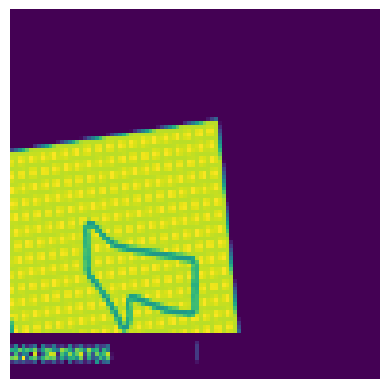

In [4]:
plt.imshow(obs[0, 0])
plt.axis("off")
plt.show()

In [5]:
print(env.observation_space)
print(env.action_space)

Box(0, 255, (2, 4, 96, 96, 1), uint8)
Box([[-1.  0.  0.]
 [-1.  0.  0.]], 1.0, (2, 3), float32)


In [6]:
sample_action = env.action_space.sample()
print("sample action", sample_action, ", action shape:", sample_action.shape, ", type:", sample_action.dtype)
observation, reward, terminated, truncated, info = env.step(sample_action)
print("observation shape:", observation.shape)
print("reward:", reward, ", terminated:", terminated, ", truncated:", truncated, ", info:", info)

sample action [[-0.06043023  0.99562085  0.72565824]
 [ 0.10156426  0.70320874  0.08175389]] , action shape: (2, 3) , type: float32
observation shape: (2, 4, 96, 96, 1)
reward: [6.77285223 8.33881857] , terminated: [False False] , truncated: [False False] , info: {}


In [7]:
@dataclass(slots=True, frozen=True)
class RolloutStep:
    observation: NDArray[np.uint8]
    action: NDArray[np.float32]
    critic_value: NDArray[np.float32]
    old_log_probs: NDArray[np.float32]
    reward: NDArray[np.float32]
    terminated: NDArray[np.bool_]
    truncated: NDArray[np.bool_]


def to_tensor_batch(minibatch: dict[str, NDArray], device: T.device) -> dict[str, T.Tensor]:
    return {k: T.from_numpy(v).to(device) for k, v in minibatch.items()}


# Rollout Buffer
class RolloutBuffer:
    def __init__(self, size: int, num_envs: int, observation_space: tuple[int, ...], action_space: tuple[int, ...], obs_dtype: np.dtype = np.dtype(np.uint8)):
        self.size = size
        self._num_envs = num_envs
        self._observation_space = observation_space
        self._action_space = action_space
        self._obs_dtype = obs_dtype
        self._buffer: dict[str, NDArray] = {}
        self._counter: int = 0
        self.reset()

    def is_full(self) -> bool:
        return self._counter == self.size

    def add(self, step: RolloutStep):
        i = self._counter
        self._buffer["observation"][:, i] = step.observation
        self._buffer["action"][:, i] = step.action
        self._buffer["critic_value"][:, i] = step.critic_value
        self._buffer["old_log_probs"][:, i] = step.old_log_probs
        self._buffer["reward"][:, i] = step.reward
        self._buffer["terminated"][:, i] = step.terminated
        self._buffer["truncated"][:, i] = step.truncated
        self._counter += 1

    @staticmethod
    def compute_returns_and_advantages(
        reward: NDArray[np.float32],
        critic_value: NDArray[np.float32],
        done: NDArray[np.bool_],
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
    ) -> tuple[NDArray[np.float32], NDArray[np.float32]]:
        delta = reward[:, :-1] + gamma * critic_value[:, 1:] * np.logical_not(done[:, :-1]) - critic_value[:, :-1]
        advantages = np.zeros_like(delta)
        last_gae_lam = 0
        for i in reversed(range(advantages.shape[1])):
            last_gae_lam = delta[:, i] + gamma * gae_lambda * last_gae_lam * np.logical_not(done[:, i])
            advantages[:, i] = last_gae_lam
        returns = advantages + critic_value[:, :-1]
        return returns, advantages

    def _build_observation_windows(self, obs: NDArray[np.uint8], done: NDArray[np.bool_], stack_size: int) -> NDArray[np.uint8]:
        """
        Returns shape (size, num_envs, stack_size, *observation_space).
        stacked[n, t] = last `stack_size` frames ending at t, for env n,
        clipped at episode boundaries (terminated/truncated) and buffer start,
        padded by repeating the earliest available frame.
        """
        T_, N, k = self.size, self._num_envs, stack_size
        # obs = self._buffer["observation"]
        # done = self._buffer["terminated"] | self._buffer["truncated"]

        stacked = np.zeros((N, T_, k) + self._observation_space, dtype=self._obs_dtype)
        for n in range(N):
            window_start = 0
            for t in range(T_):
                if t > 0 and done[n, t - 1]:
                    window_start = t
                lo = max(window_start, t - k + 1)
                frames = obs[n, lo:t + 1]
                pad = k - frames.shape[0]
                if pad > 0:
                    frames = np.concatenate([np.repeat(frames[:1], pad, axis=0), frames], axis=0)
                stacked[n, t] = frames
        return stacked

    def get_flat_trajectory(self, stack_size: int, gamma: float = 0.99, gae_lambda: float = 0.95) -> dict[str, NDArray]:
        done = np.logical_or(self._buffer["terminated"], self._buffer["truncated"])
        returns, advantages = self.compute_returns_and_advantages(
            self._buffer["reward"], self._buffer["critic_value"], done, gamma, gae_lambda,
        )
        obs_windows = self._build_observation_windows(self._buffer["observation"], done, stack_size=stack_size)
        flat = {
            "observation": obs_windows[:, :-1].reshape(-1, stack_size, *self._observation_space),
            "action": self._buffer["action"][:, :-1].reshape(-1, *self._action_space),
            "old_log_probs": self._buffer["old_log_probs"][:, :-1].reshape(-1),
            "returns": returns.reshape(-1),
            "advantages": advantages.reshape(-1),
        }
        return flat

    def get_iid_minibatches(self, minibatch_size: int, stack_size: int, rng: np.random.Generator) -> Iterator[dict[str, NDArray]]:
        flat = self.get_flat_trajectory(stack_size)
        n = flat["returns"].shape[0]
        indices = rng.permutation(n)
        for start in range(0, n, minibatch_size):
            idx = indices[start:start + minibatch_size]
            yield {k: v[idx] for k, v in flat.items()}

    def reset(self):
        self._buffer = {
            "observation": np.zeros((self._num_envs, self.size) + self._observation_space, self._obs_dtype),
            "action": np.zeros((self._num_envs, self.size) + self._action_space, np.float32),
            "critic_value": np.zeros((self._num_envs, self.size), np.float32),
            "old_log_probs": np.zeros((self._num_envs, self.size), np.float32),
            "reward": np.zeros((self._num_envs, self.size), np.float32),
            "truncated": np.zeros((self._num_envs, self.size), np.bool_),
            "terminated": np.zeros((self._num_envs, self.size), np.bool_),
        }
        self._counter: int = 0


In [8]:
buffer = RolloutBuffer(BATCH_SIZE, NUM_ENVS, env.observation_space.shape[-3:], env.action_space.shape[-1:])

In [9]:
class CNN(nn.Module):
    def __init__(self, observation_dim: int):
        super().__init__()
        self._network = nn.Sequential(
            nn.Conv2d(observation_dim, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(4096, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )

    def forward(self, x: T.Tensor) -> T.Tensor:
        return self._network(x)

class Actor(nn.Module):
    def __init__(self, action_dim: int):
        super().__init__()
        self._network = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim),
        )
        self._log_std = nn.Parameter(T.zeros(action_dim))

    def forward(self, x: T.Tensor) -> Distribution:
        mean = self._network(x)
        std = self._log_std.exp()
        return TransformedDistribution(
            Normal(mean, std),
            transforms=ComposeTransform(
                [
                    TanhTransform(),
                    AffineTransform(loc=T.Tensor([0, 0.5, 0.5]), scale=T.Tensor([1., 0.5, 0.5])),
                ]
            )
        )

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self._network = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, x: T.Tensor) -> T.Tensor:
        return self._network(x).squeeze_(-1)


class PPONetwork(nn.Module):
    def __init__(self, observation_dim: int, action_dim: int, stack_size: int):
        super().__init__()

        self.cnn = CNN(observation_dim)
        self.sequence_encoder = nn.Conv1d(
            512, 512, kernel_size=stack_size, bias=False
        )
        self.actor = Actor(action_dim)
        self.critic = Critic()

    def forward(self, observation: T.Tensor) -> tuple[Distribution, T.Tensor]:
        x = observation.view(-1, *observation.shape[-3:])
        x = self.cnn(x)

        x = x.view(observation.shape[0], -1, x.shape[-1])
        x = self.sequence_encoder(x.permute(0, 2, 1)).squeeze_(-1)

        action_dist = self.actor(x)
        value = self.critic(x)

        return action_dist, value


class Agent:
    def __init__(self, observation_dim: int, action_dim: int, stack_size: int):
        self._observation_dim = observation_dim
        self._action_dim = action_dim
        self._stack_size = stack_size
        self._device = T.device("cuda" if T.cuda.is_available() else "cpu")
        self._network = PPONetwork(
            observation_dim,
            action_dim,
            stack_size
        ).to(self._device)

    def _preprocess_observation(self, observation: NDArray[np.uint8] | T.Tensor) -> T.Tensor:
        if isinstance(observation, np.ndarray):
            # freshly created tensor — safe to mutate in place
            observation_tensor = T.from_numpy(observation).to(self._device, T.float32)
            observation_tensor.div_(255. / 2.).sub_(1.)
        else:
            # caller-owned tensor — don't mutate their storage
            observation_tensor = observation.to(self._device, T.float32)
            observation_tensor = observation_tensor.div(255. / 2.).sub_(1.)

        return observation_tensor.permute(0, 1, 4, 2, 3)

    def evaluate_actions(self, observation: NDArray[np.uint8] | T.Tensor, action: NDArray[np.float32] | T.Tensor) -> tuple[T.Tensor, T.Tensor, Distribution]:
        obs = self._preprocess_observation(observation)
        result: tuple[Distribution, T.Tensor] = self._network(obs)
        action_dist, value = result

        action_tensor = T.from_numpy(action) if isinstance(action, np.ndarray) else action
        log_probs = action_dist.log_prob(action_tensor.to(self._device)).sum(dim=-1)
        return log_probs, value, action_dist

    def act(self, observation: NDArray[np.uint8]) -> tuple[NDArray[np.float32], NDArray[np.float32], NDArray[np.float32]]:
        obs = self._preprocess_observation(observation)
        result: tuple[Distribution, T.Tensor] = self._network(obs)
        action_dist, value = result
        action = action_dist.sample()
        log_probs = action_dist.log_prob(action).sum(dim=-1)
        return action.detach().cpu().numpy(), log_probs.detach().cpu().numpy(), value.detach().cpu().numpy()

In [10]:
agent = Agent(env.observation_space.shape[-1], env.action_space.shape[-1], stack_size=STACK_SIZE)

In [11]:
class RecordVideoCallback:
    def __init__(self, env_id: str, agent: Agent, video_dir: str):
        self.agent = agent
        self.video_dir = video_dir
        self.env = self._make_env(env_id, self.agent._stack_size)

    def _make_env(self, env_id: str, stack_size: int):
        return gym.make_vec(
            env_id,
            num_envs=1,
            vectorization_mode=gym.VectorizeMode.SYNC,
            render_mode="rgb_array",
            continuous=True,
            wrappers=[
                lambda env: gym.wrappers.RecordVideo(
                    env, self.video_dir, episode_trigger=lambda ep: True
                ),
                lambda env: gym.wrappers.GrayscaleObservation(env, keep_dim=True),
                lambda env: gym.wrappers.FrameStackObservation(env, stack_size=stack_size),
                lambda env: gym.wrappers.RecordEpisodeStatistics(env),
            ]
        )

    def record(self):
        state, _ = self.env.reset()
        done = False
        while not done:
            action, _, _ = self.agent.act(state)
            state, _, terminated, truncated, info = self.env.step(action)
            done = np.logical_or(terminated, truncated).any()
        print(info)
        return

record_video_callback = RecordVideoCallback(
    env_id="CarRacing-v3",
    agent=agent,
    video_dir="./videos/",
)
        

In [20]:
class MetricsLogger(Protocol):
    def log_metrics(self, metrics: dict[str, float], step: int) -> None: ...

class TrainingCallback(Protocol):
    def on_start(self, *args, **kwargs) -> None: ...
    def on_step(self, *args, **kwargs) -> None: ...
    def on_end(self, *args, **kwargs) -> None: ...
    def on_epoch(self, *args, **kwargs) -> None: ...

class PPOTrainer:
    def __init__(
        self,
        agent: Agent,
        ppo_epsilon: float = 0.2,
        critic_beta: float = 0.5,
        entropy_coef: float = 0.001,
        callbacks: list[TrainingCallback] | None = None,
        logger: MetricsLogger | None = None,
    ):
        self._agent = agent
        self._optimizer = Adam(agent._network.parameters(), lr=3e-4, eps=1e-5)
        self.ppo_epsilon = ppo_epsilon
        self.critic_beta = critic_beta
        self.entropy_coef = entropy_coef
        self.critic_loss_fn = nn.MSELoss()
        self._callbacks = callbacks
        self._logger = logger
        self._step = 0

    def train_step(self, advantages: T.Tensor, returns: T.Tensor, old_log_probs: T.Tensor, observation: T.Tensor, action: T.Tensor) -> dict[str, float]:
        actor_loss, critic_loss, entropy_loss = self.calculate_losses(advantages, returns, old_log_probs, observation, action)
        loss = actor_loss + self.critic_beta * critic_loss - self.entropy_coef * entropy_loss

        self._optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self._agent._network.parameters(), 0.5)
        self._optimizer.step()

        metrics = {
            "loss/total": loss.detach().item(),
            "loss/actor": actor_loss.detach().item(),
            "loss/critic": critic_loss.detach().item(),
            "loss/entropy": entropy_loss.detach().item(),
        }

        self._step += 1
        if self._logger is not None:
            self._logger.log_metrics(metrics, step=self._step)

        return metrics

    def _actor_loss(self, advantages: T.Tensor, log_probs: T.Tensor, old_log_probs: T.Tensor) -> T.Tensor:
        ratio = (log_probs - old_log_probs).exp_()
        clipped_ratio = ratio.clamp(min=1 - self.ppo_epsilon, max=1 + self.ppo_epsilon)
        surrogate_loss = -T.minimum(ratio * advantages, clipped_ratio * advantages)
        return surrogate_loss.mean()

    def _critic_loss(self, returns: T.Tensor, values: T.Tensor) -> T.Tensor:
        critic_loss = self.critic_loss_fn(returns, values)
        return critic_loss

    def _entropy_loss(self, log_probs: T.Tensor) -> T.Tensor:
        return -log_probs.mean()
    # def _entropy_loss(self, dist: Distribution) -> T.Tensor:
    #     return dist.entropy().sum(-1).mean()

    def calculate_losses(self, advantages: T.Tensor, returns: T.Tensor, old_log_probs: T.Tensor, observation: T.Tensor, action: T.Tensor) -> tuple[T.Tensor, T.Tensor, T.Tensor]:
        log_probs, values, dist = self._agent.evaluate_actions(observation, action)
        normalized_advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        actor_loss = self._actor_loss(normalized_advantages, log_probs, old_log_probs)
        critic_loss = self._critic_loss(returns, values)
        entropy_loss = self._entropy_loss(log_probs)
        return actor_loss, critic_loss, entropy_loss

    def on_start(self, *args, **kwargs):
        for callback in self._callbacks:
            callback.on_start(*args, **kwargs)

    def on_step(self, *args, **kwargs):
        for callback in self._callbacks:
            callback.on_step(*args, **kwargs)

    def on_end(self, *args, **kwargs):
        for callback in self._callbacks:
            callback.on_end(*args, **kwargs)

    def on_epoch(self, *args, **kwargs):
        for callback in self._callbacks:
            callback.on_epoch(*args, **kwargs)

    def train(self, buffer: RolloutBuffer, epochs: int, minibatch_size: int, rng: np.random.Generator):
        self.on_start()
        for epoch in range(epochs):
            for minibatch in buffer.get_iid_minibatches(minibatch_size, STACK_SIZE, rng):
                tensor_batch = to_tensor_batch(minibatch, self._device)
                self.train_step(**tensor_batch)
                self.on_step()
            self.on_epoch()
        self.on_end()
        buffer.reset()


In [21]:
trainer = PPOTrainer(agent)

In [22]:
class RolloutCollector:
    def __init__(self, env: gym.vector.VectorEnv, buffer: RolloutBuffer, trainer: PPOTrainer, epochs: int, minibatch_size: int):
        self.env = env
        self.buffer = buffer
        self.trainer = trainer
        self.epochs = epochs
        self.minibatch_size = minibatch_size

    def run(self, training_steps: int, rng: np.random.Generator):
        state, _ = self.env.reset()
        self.buffer.reset()

        for i in tqdm(range(training_steps)):
            action, log_probs, critic_value = self.trainer._agent.act(state)
            next_state, reward, terminated, truncated, info = self.env.step(action)

            self.buffer.add(RolloutStep(
                observation=state[:, -1, ...],
                action=action,
                critic_value=critic_value,
                old_log_probs=log_probs,
                reward=reward,
                terminated=terminated,
                truncated=truncated,
            ))

            state = next_state

            if self.buffer.is_full():
                self.trainer.train(self.buffer, epochs=self.epochs, minibatch_size=self.minibatch_size, rng=rng)
                self.buffer.reset()

In [ ]:

rng = np.random.default_rng(seed=42)

training_steps = 10_000
rollout_collector = RolloutCollector(env, buffer, trainer, EPOCHS, MINIBATCH_SIZE)

rollout_collector.run(training_steps, rng)



  0%|          | 11/10000 [00:00<09:18, 17.88it/s]

In [ ]:
state, _ = env.reset()

training_steps = 100

for i in tqdm(range(training_steps)):

    # select action
    action, log_probs, critic_value = agent.act(state)

    # perform action
    next_state, reward, terminated, truncated, info = env.step(action)
    print(action, reward, truncated | terminated)